# Importations et configuration

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

# Configuration des avertissements
warnings.filterwarnings('ignore')

# Configuration des styles graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Bibliothèques importées avec succès!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

✅ Bibliothèques importées avec succès!
Pandas version: 2.3.3
NumPy version: 1.24.3


#  Fonction de chargement et exploration des données

In [2]:
# %% [markdown]
# ## Fonction de chargement et exploration initiale
# 
# Cette fonction charge le dataset CSV et fournit une exploration complète :
# - Dimensions des données
# - Aperçu (premières et dernières lignes)
# - Types de données
# - Statistiques descriptives
# - Valeurs manquantes

# %% [code]
def load_and_explore_data(filepath):
    """Charge et explore le dataset"""
    print("=" * 60)
    print("CHARGEMENT ET EXPLORATION DES DONNÉES")
    print("=" * 60)
    
    # 1. Chargement des données
    print(f"\n1. Chargement depuis: {filepath}")
    df = pd.read_csv(filepath)
    
    # 2. Affichage des informations de base
    print(f"\n2. Dimensions: {df.shape[0]} lignes × {df.shape[1]} colonnes")
    print(f"\n3. Aperçu des données (premières lignes):")
    print(df.head())
    
    print(f"\n4. Aperçu des données (dernières lignes):")
    print(df.tail())
    
    print(f"\n5. Types de données:")
    print(df.dtypes)
    
    print(f"\n6. Statistiques descriptives:")
    print(df.describe(include='all'))
    
    # 3. Vérification des valeurs manquantes
    print(f"\n7. Valeurs manquantes par colonne:")
    missing = df.isnull().sum()
    missing_data = pd.DataFrame({
        'Colonne': missing.index,
        'Valeurs_manquantes': missing.values,
        'Pourcentage': (missing.values / len(df)) * 100
    })
    print(missing_data[missing_data['Valeurs_manquantes'] > 0])
    
    # 4. Conversion du timestamp si nécessaire
    if 'timestamp' in df.columns:
        print(f"\n8. Conversion de la colonne 'timestamp'...")
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        print(f"   Période: {df['timestamp'].min()} à {df['timestamp'].max()}")
        print(f"   Durée: {(df['timestamp'].max() - df['timestamp'].min()).days} jours")
        print(f"   Fréquence: ~{len(df) / ((df['timestamp'].max() - df['timestamp'].min()).days + 1):.1f} points/jour")
    
    return df

In [3]:
filepath = r"C:\Users\hp\Desktop\works\donnees\modele_3966_Aug_Dec2025.csv"

# Charger les données
try:
    df = load_and_explore_data(filepath)
    print(f"\n✅ Données chargées avec succès!")
    print(f"   Shape: {df.shape}")
    
    # Afficher les colonnes disponibles
    print(f"\n📊 Colonnes disponibles ({len(df.columns)}):")
    for i, col in enumerate(df.columns, 1):
        print(f"   {i:2d}. {col} ({df[col].dtype})")
        
except FileNotFoundError:
    print(f"\n❌ ERREUR: Fichier non trouvé à l'emplacement: {filepath}")
    print("Vérifiez le chemin et réessayez.")
except Exception as e:
    print(f"\n❌ ERREUR inattendue: {e}")
    import traceback
    traceback.print_exc()

CHARGEMENT ET EXPLORATION DES DONNÉES

1. Chargement depuis: C:\Users\hp\Desktop\works\donnees\modele_3966_Aug_Dec2025.csv

2. Dimensions: 3501 lignes × 14 colonnes

3. Aperçu des données (premières lignes):
                   timestamp         P0         P1         P2   humidity  \
0  2025-08-08 03:00:00+00:00  22.111431  36.489514  30.930691  84.350000   
1  2025-08-08 04:00:00+00:00  23.508573  40.748386  32.879269  72.721523   
2  2025-08-08 05:00:00+00:00  24.905715  45.007257  34.827846  61.093046   
3  2025-08-08 06:00:00+00:00  24.704000  50.080000  35.366000  51.743310   
4  2025-08-08 07:00:00+00:00  40.081250  70.162500  54.506250  51.725000   

   temperature  heure jour_semaine  periode   P2_lag_1   P2_lag_2   P2_lag_3  \
0    15.250000      3       Friday  semaine  33.375576  35.820461  38.265346   
1    18.704283      4       Friday  semaine  30.930691  33.375576  35.820461   
2    22.158567      5       Friday  semaine  32.879269  30.930691  33.375576   
3    25.460561 

#  Fonction d'analyse de séries temporelles

In [4]:
#cette fonction analyse la série temporelle avec :
# - Statistiques descriptives
# - Visualisations temporelles
# - Analyse de saisonnalité
# - Autocorrélations

# %% [code]
def analyze_time_series(df, target_col='P2'):
    """Analyse spécifique de la série temporelle"""
    print("\n" + "=" * 60)
    print("ANALYSE DE LA SÉRIE TEMPORELLE")
    print("=" * 60)
    
    if 'timestamp' not in df.columns:
        print("❌ ERREUR: Colonne 'timestamp' non trouvée!")
        return
    
    # 1. Configuration de l'index temporel
    df_time = df.set_index('timestamp').copy()
    df_time = df_time.sort_index()  # Tri chronologique
    
    # 2. Analyse de la variable cible
    print(f"\n1. Analyse de la variable cible '{target_col}':")
    if target_col in df_time.columns:
        target_series = df_time[target_col]
        print(f"   - Moyenne: {target_series.mean():.2f}")
        print(f"   - Écart-type: {target_series.std():.2f}")
        print(f"   - Min/Max: {target_series.min():.2f}/{target_series.max():.2f}")
        print(f"   - Médiane: {target_series.median():.2f}")
        print(f"   - Q1/Q3: {target_series.quantile(0.25):.2f}/{target_series.quantile(0.75):.2f}")
        
        return df_time, target_series
    else:
        print(f"❌ ERREUR: Colonne '{target_col}' non trouvée!")
        return None, None

#  Préparation des données pour l'analyse cas de "P2"

In [5]:
target_col = 'P2'  # Vous pouvez changer cela si nécessaire

# Préparer les données temporelles
df_time, target_series = analyze_time_series(df, target_col)

if df_time is not None:
    print(f"\n✅ Données temporelles préparées:")
    print(f"   Index: {df_time.index.name}")
    print(f"   Période: {df_time.index.min()} à {df_time.index.max()}")
    print(f"   Nombre de points: {len(df_time)}")
    

    print(f"\n📊 Colonnes temporelles disponibles:")
    for col in df_time.columns:
        print(f"   - {col} ({df_time[col].dtype})")


ANALYSE DE LA SÉRIE TEMPORELLE

1. Analyse de la variable cible 'P2':
   - Moyenne: 34.16
   - Écart-type: 12.01
   - Min/Max: 9.61/421.31
   - Médiane: 32.82
   - Q1/Q3: 27.75/38.54

✅ Données temporelles préparées:
   Index: timestamp
   Période: 2025-08-08 03:00:00+00:00 à 2025-12-31 23:00:00+00:00
   Nombre de points: 3501

📊 Colonnes temporelles disponibles:
   - P0 (float64)
   - P1 (float64)
   - P2 (float64)
   - humidity (float64)
   - temperature (float64)
   - heure (int64)
   - jour_semaine (object)
   - periode (object)
   - P2_lag_1 (float64)
   - P2_lag_2 (float64)
   - P2_lag_3 (float64)
   - P2_lag_24 (float64)
   - P2_lag_168 (float64)


In [6]:
# ## Analyse des variables catégorielles

# %% [code]
if df_time is not None:
    print(f"\n2. Analyse des variables catégorielles:")
    for col in ['jour_semaine', 'periode']:
        if col in df_time.columns:
            print(f"\n   - {col}:")
            print(f"     Nombre de valeurs uniques: {df_time[col].nunique()}")
            print(f"     Exemples: {df_time[col].unique()[:10]}")
            print(f"     Fréquence des principales valeurs:")
            value_counts = df_time[col].value_counts().head(10)
            for val, count in value_counts.items():
                print(f"       {val}: {count} ({count/len(df_time)*100:.1f}%)")


2. Analyse des variables catégorielles:

   - jour_semaine:
     Nombre de valeurs uniques: 7
     Exemples: ['Friday' 'Saturday' 'Sunday' 'Monday' 'Tuesday' 'Wednesday' 'Thursday']
     Fréquence des principales valeurs:
       Saturday: 504 (14.4%)
       Sunday: 504 (14.4%)
       Monday: 504 (14.4%)
       Tuesday: 504 (14.4%)
       Wednesday: 504 (14.4%)
       Friday: 501 (14.3%)
       Thursday: 480 (13.7%)

   - periode:
     Nombre de valeurs uniques: 2
     Exemples: ['semaine' 'weekend']
     Fréquence des principales valeurs:
       semaine: 2493 (71.2%)
       weekend: 1008 (28.8%)


# Visuel

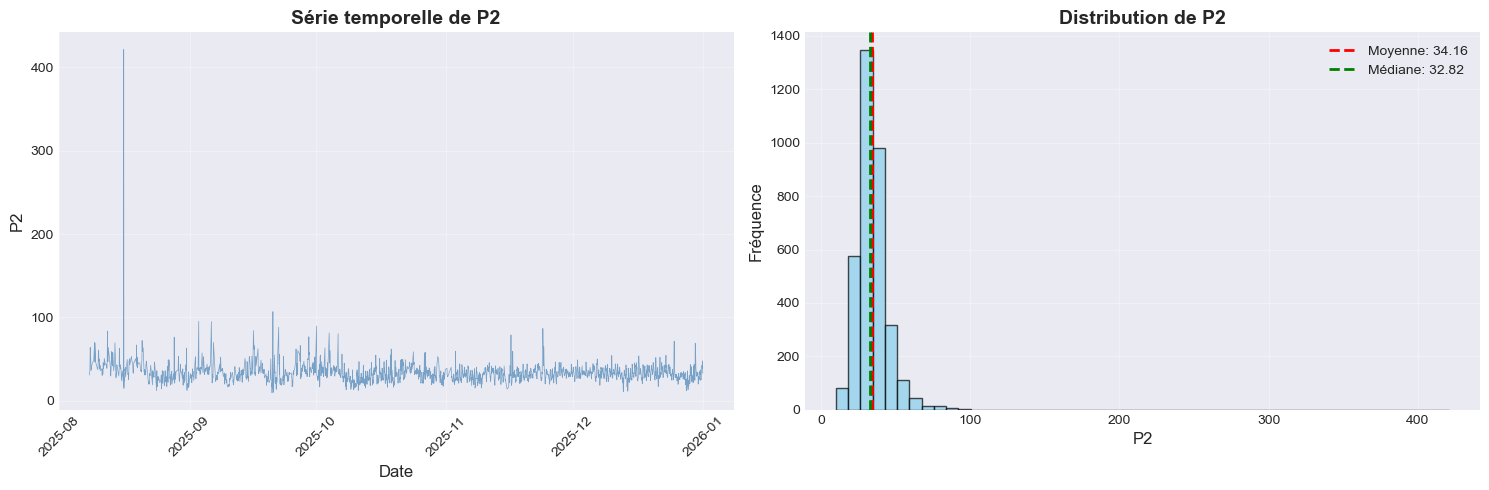

✅ Graphiques 1 et 2 générés


In [8]:
# %% [markdown]
# ## Visualisations temporelles - Partie 1
# 
# Série temporelle et distribution

# %% [code]
if df_time is not None and target_series is not None:
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Graphique 1: Série temporelle complète
    axes[0].plot(target_series.index, target_series.values, linewidth=0.5, alpha=0.7, color='steelblue')
    axes[0].set_title(f'Série temporelle de {target_col}', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Date', fontsize=12)
    axes[0].set_ylabel(target_col, fontsize=12)
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(True, alpha=0.3)
    
    # Graphique 2: Distribution
    axes[1].hist(target_series, bins=50, edgecolor='black', alpha=0.7, color='skyblue')
    axes[1].axvline(target_series.mean(), color='red', linestyle='--', 
                    linewidth=2, label=f'Moyenne: {target_series.mean():.2f}')
    axes[1].axvline(target_series.median(), color='green', linestyle='--', 
                    linewidth=2, label=f'Médiane: {target_series.median():.2f}')
    axes[1].set_title(f'Distribution de {target_col}', fontsize=14, fontweight='bold')
    axes[1].set_xlabel(target_col, fontsize=12)
    axes[1].set_ylabel('Fréquence', fontsize=12)
    axes[1].legend(loc='best')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Graphiques 1 et 2 générés")

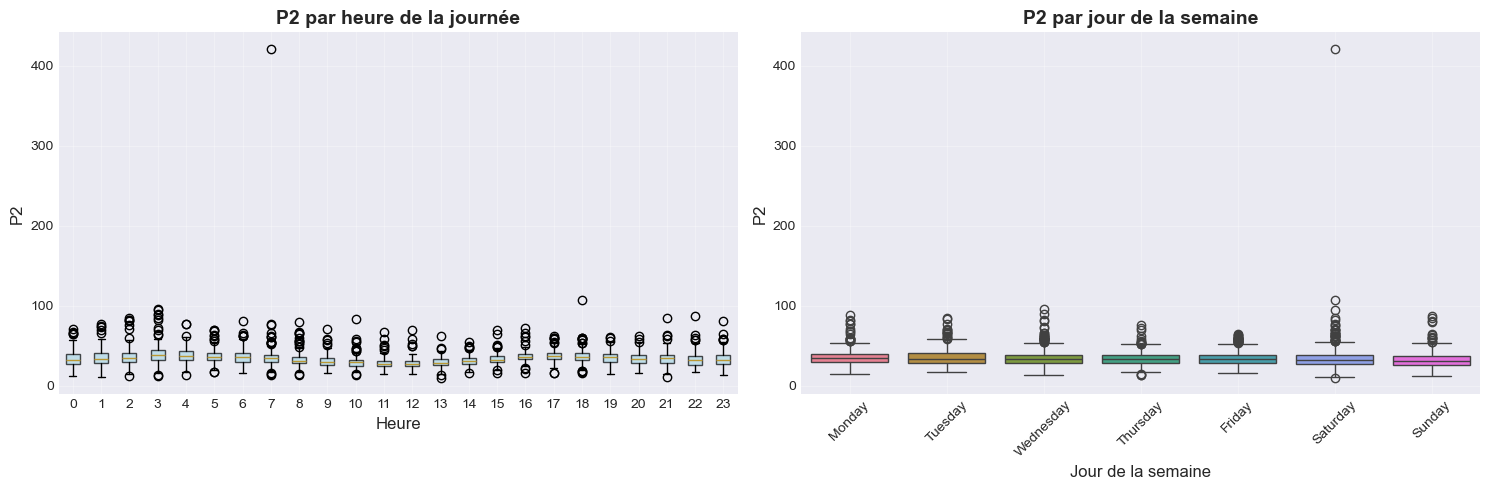

✅ Graphiques 3 et 4 générés


In [9]:
# %% [markdown]
# ## Visualisations temporelles - Partie 2
# 
# Analyse par heure et par jour de la semaine

# %% [code]
if df_time is not None and target_series is not None:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Graphique 3: Boxplot par heure (si numérique)
    if 'heure' in df_time.columns:
        # Vérifier si 'heure' est numérique
        if pd.api.types.is_numeric_dtype(df_time['heure']):
            hourly_data = []
            hours = sorted(df_time['heure'].unique())
            
            for h in hours:
                mask = df_time['heure'] == h
                if mask.any():
                    hourly_data.append(df_time[mask][target_col].values)
            
            if hourly_data:  # Vérifier qu'il y a des données
                box = axes[0].boxplot(hourly_data, positions=range(len(hours)), patch_artist=True)
                
                # Colorer les boxplots
                for patch in box['boxes']:
                    patch.set_facecolor('lightblue')
                    patch.set_alpha(0.7)
                
                axes[0].set_xticks(range(len(hours)))
                axes[0].set_xticklabels([str(h) for h in hours])
                axes[0].set_title(f'{target_col} par heure de la journée', fontsize=14, fontweight='bold')
                axes[0].set_xlabel('Heure', fontsize=12)
                axes[0].set_ylabel(target_col, fontsize=12)
                axes[0].grid(True, alpha=0.3)
        else:
            axes[0].text(0.5, 0.5, "'heure' n'est pas numérique\nType: {}".format(df_time["heure"].dtype),
                       ha='center', va='center', transform=axes[0].transAxes, fontsize=12)
            axes[0].set_title('Heure - Type de données')
    else:
        axes[0].text(0.5, 0.5, "Colonne 'heure' non trouvée",
                   ha='center', va='center', transform=axes[0].transAxes, fontsize=12)
        axes[0].set_title('Heure - Absente')
    
    # Graphique 4: Boxplot par jour de la semaine
    if 'jour_semaine' in df_time.columns:
        # Créer un DataFrame pour seaborn
        temp_df = df_time.reset_index()[['jour_semaine', target_col]].copy()
        
        # Définir l'ordre logique des jours
        jours_francais = ['Lundi', 'Mardi', 'Mercredi', 'Jeudi', 'Vendredi', 'Samedi', 'Dimanche']
        jours_anglais = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
        
        # Trouver l'ordre qui correspond à nos données
        jours_uniques = temp_df['jour_semaine'].unique()
        ordre_found = []
        
        for jour_list in [jours_francais, jours_anglais]:
            for j in jour_list:
                if j in jours_uniques:
                    ordre_found.append(j)
        
        if ordre_found and len(ordre_found) <= 20:
            # Utiliser seaborn pour un meilleur rendu
            import seaborn as sns
            axes[1].clear()
            
            temp_df['jour_semaine'] = pd.Categorical(
                temp_df['jour_semaine'], 
                categories=ordre_found, 
                ordered=True
            )
            
            sns.boxplot(data=temp_df, x='jour_semaine', y=target_col, 
                       ax=axes[1], order=ordre_found, palette='husl')
            
            axes[1].tick_params(axis='x', rotation=45)
            axes[1].set_title(f'{target_col} par jour de la semaine', fontsize=14, fontweight='bold')
            axes[1].set_xlabel('Jour de la semaine', fontsize=12)
            axes[1].set_ylabel(target_col, fontsize=12)
            axes[1].grid(True, alpha=0.3)
        else:
            axes[1].text(0.5, 0.5, f"Trop de catégories ({len(jours_uniques)})\nou ordre non défini",
                       ha='center', va='center', transform=axes[1].transAxes, fontsize=12)
            axes[1].set_title('Jour de la semaine')
    else:
        axes[1].text(0.5, 0.5, "Colonne 'jour_semaine' non trouvée",
                   ha='center', va='center', transform=axes[1].transAxes, fontsize=12)
        axes[1].set_title('Jour de la semaine - Absente')
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Graphiques 3 et 4 générés")

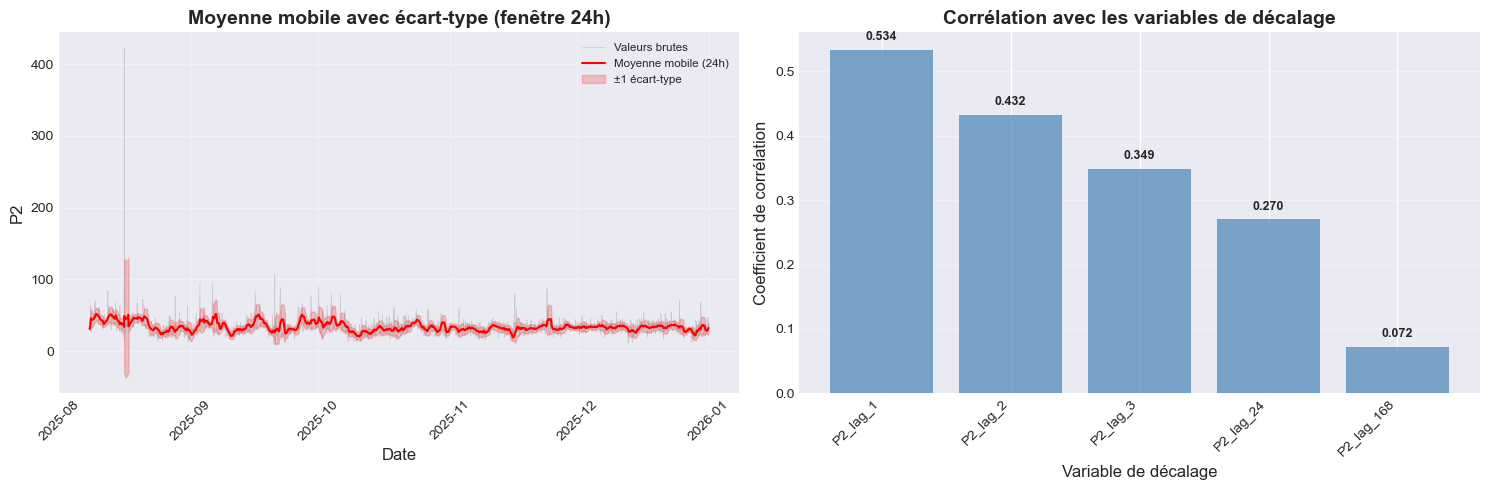

✅ Graphiques 5 et 6 générés


In [10]:
# %% [markdown]
# ## Visualisations temporelles - Partie 3
# 
# Moyenne mobile et corrélations

# %% [code]
if df_time is not None and target_series is not None:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Graphique 5: Moyenne mobile
    rolling_mean = target_series.rolling(window=24, min_periods=1).mean()  # 24h
    rolling_std = target_series.rolling(window=24, min_periods=1).std()
    
    axes[0].plot(target_series.index, target_series, alpha=0.3, label='Valeurs brutes', 
                linewidth=0.5, color='gray')
    axes[0].plot(rolling_mean.index, rolling_mean, 'r-', linewidth=1.5, 
                label='Moyenne mobile (24h)')
    axes[0].fill_between(rolling_mean.index, 
                         rolling_mean - rolling_std, 
                         rolling_mean + rolling_std, 
                         alpha=0.2, color='red', label='±1 écart-type')
    
    axes[0].set_title('Moyenne mobile avec écart-type (fenêtre 24h)', 
                     fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Date', fontsize=12)
    axes[0].set_ylabel(target_col, fontsize=12)
    axes[0].legend(loc='best', fontsize='small')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(True, alpha=0.3)
    
    # Graphique 6: Corrélation avec les lags
    lag_cols = [col for col in df_time.columns if 'lag' in col.lower()]
    
    if lag_cols:
        correlations = {}
        for lag_col in lag_cols:
            if lag_col in df_time.columns:
                corr_value = df_time[[target_col, lag_col]].corr().iloc[0, 1]
                if not pd.isna(corr_value):
                    correlations[lag_col] = corr_value
        
        if correlations:
            colors = ['steelblue' if v >= 0 else 'coral' for v in correlations.values()]
            bars = axes[1].bar(range(len(correlations)), list(correlations.values()), 
                              color=colors, alpha=0.7)
            
            axes[1].set_xticks(range(len(correlations)))
            axes[1].set_xticklabels(list(correlations.keys()), rotation=45, ha='right')
            axes[1].set_title('Corrélation avec les variables de décalage', 
                             fontsize=14, fontweight='bold')
            axes[1].set_xlabel('Variable de décalage', fontsize=12)
            axes[1].set_ylabel('Coefficient de corrélation', fontsize=12)
            axes[1].grid(True, alpha=0.3, axis='y')
            
            # Ajouter les valeurs sur les barres
            for i, (bar, v) in enumerate(zip(bars, correlations.values())):
                height = bar.get_height()
                axes[1].text(bar.get_x() + bar.get_width()/2., 
                            height + 0.01 * (1 if v >= 0 else -1), 
                            f'{v:.3f}', ha='center', va='bottom' if v >= 0 else 'top', 
                            fontsize=9, fontweight='bold')
        else:
            axes[1].text(0.5, 0.5, 'Pas de corrélations calculables\navec les lag variables',
                       ha='center', va='center', transform=axes[1].transAxes, fontsize=12)
            axes[1].set_title('Corrélations Lag')
    else:
        axes[1].text(0.5, 0.5, 'Aucune variable "lag" trouvée',
                   ha='center', va='center', transform=axes[1].transAxes, fontsize=12)
        axes[1].set_title('Corrélations Lag')
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Graphiques 5 et 6 générés")


4. Analyse de saisonnalité avancée:


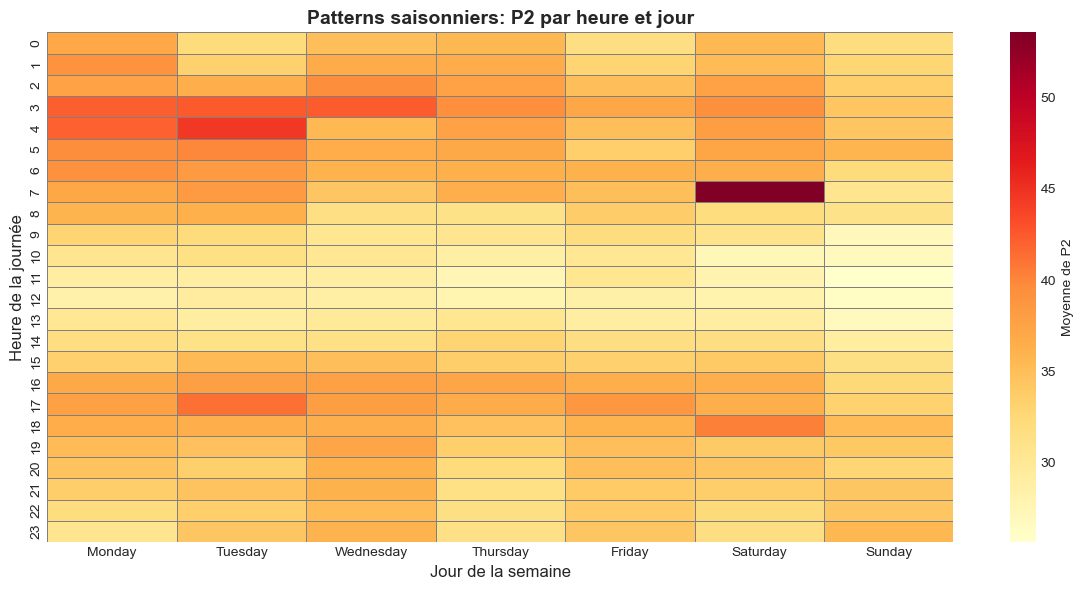

✅ Heatmap créée: heure vs jour_semaine

5. Analyse par 'periode':
   Valeurs uniques: ['semaine', 'weekend']


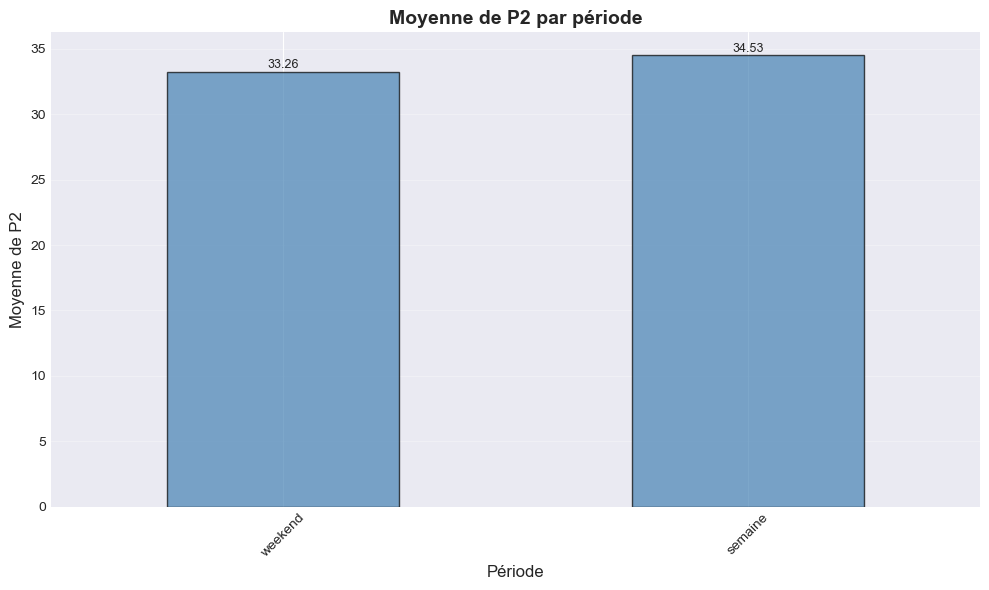

✅ Graphique période généré


In [11]:
# %% [markdown]
# ## Analyse de saisonnalité avancée
# 
# Heatmaps et patterns saisonniers

# %% [code]
if df_time is not None and target_series is not None:
    print(f"\n4. Analyse de saisonnalité avancée:")
    
    if 'heure' in df_time.columns and pd.api.types.is_numeric_dtype(df_time['heure']):
        # Heatmap heure × jour_semaine
        temp_df = df_time.reset_index()[['heure', 'jour_semaine', target_col]].copy()
        
        # Préparer la heatmap
        if 'jour_semaine' in temp_df.columns and len(temp_df['jour_semaine'].unique()) <= 15:
            pivot_table = temp_df.pivot_table(
                values=target_col,
                index='heure',
                columns='jour_semaine',
                aggfunc='mean'
            )
            
            # Trier les colonnes logiquement si possible
            jours_ordre = ['Lundi', 'Mardi', 'Mercredi', 'Jeudi', 'Vendredi', 'Samedi', 'Dimanche',
                          'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
            jours_presents = [j for j in jours_ordre if j in pivot_table.columns]
            
            if jours_presents:
                pivot_table = pivot_table[jours_presents]
            
            fig, ax = plt.subplots(figsize=(12, 6))
            
            sns.heatmap(pivot_table, cmap='YlOrRd', ax=ax, 
                       cbar_kws={'label': f'Moyenne de {target_col}'},
                       linewidths=0.5, linecolor='gray')
            
            ax.set_title(f'Patterns saisonniers: {target_col} par heure et jour', 
                        fontsize=14, fontweight='bold')
            ax.set_xlabel('Jour de la semaine', fontsize=12)
            ax.set_ylabel('Heure de la journée', fontsize=12)
            
            plt.tight_layout()
            plt.show()
            
            print(f"✅ Heatmap créée: heure vs jour_semaine")
        else:
            print(f"⚠️  Heatmap non créée: jour_semaine a trop de catégories ou est absente")
    
    # Analyse par période si disponible
    if 'periode' in df_time.columns:
        print(f"\n5. Analyse par 'periode':")
        print(f"   Valeurs uniques: {list(df_time['periode'].unique())}")
        
        fig, ax = plt.subplots(figsize=(10, 6))
        period_groups = df_time.groupby('periode')[target_col].mean().sort_values()
        
        bars = period_groups.plot(kind='bar', ax=ax, color='steelblue', alpha=0.7, 
                                 edgecolor='black')
        
        ax.set_title(f'Moyenne de {target_col} par période', fontsize=14, fontweight='bold')
        ax.set_xlabel('Période', fontsize=12)
        ax.set_ylabel(f'Moyenne de {target_col}', fontsize=12)
        ax.tick_params(axis='x', rotation=45)
        ax.grid(True, alpha=0.3, axis='y')
        
        # Ajouter les valeurs sur les barres
        for i, (bar, val) in enumerate(zip(bars.patches, period_groups.values)):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                   f'{val:.2f}', ha='center', va='bottom', fontsize=9)
        
        plt.tight_layout()
        plt.show()
        
        print(f"✅ Graphique période généré")

In [19]:
# %% [markdown]
# ## Analyse d'autocorrélation
# 
# Fonctions d'autocorrélation (ACF) et d'autocorrélation partielle (PACF)
# Pour identifier la structure ARIMA

# %% [code]
if df_time is not None and target_series is not None:
    print(f"\n6. Analyse d'autocorrélation (premiers lags):")
    
    try:
        from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
        
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
        
        # ACF - Autocorrelation Function
        plot_acf(target_series, lags=48, ax=ax1, alpha=0.05)
        ax1.set_title('Autocorrélation (ACF) - 48 premiers lags (2 jours)', 
                     fontsize=14, fontweight='bold')
        ax1.set_xlabel('Lag (heures)', fontsize=12)
        ax1.set_ylabel('Corrélation', fontsize=12)
        ax1.grid(True, alpha=0.3)
        
        # PACF - Partial Autocorrelation Function
        plot_pacf(target_series, lags=48, ax=ax2, alpha=0.05)
        ax2.set_title('Autocorrélation Partielle (PACF) - 48 premiers lags (2 jours)', 
                     fontsize=14, fontweight='bold')
        ax2.set_xlabel('Lag (heures)', fontsize=12)
        ax2.set_ylabel('Corrélation partielle', fontsize=12)
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        print("✅ Graphs ACF/PACF générés avec succès")
        print("   Ces graphiques aident à identifier l'ordre des modèles ARIMA")
        
    except ImportError:
        print("⚠️  Statsmodels non disponible. Installation recommandée:")
        print("   pip install statsmodels")
    except Exception as e:
        print(f"⚠️  Erreur ACF/PACF: {e}")


6. Analyse d'autocorrélation (premiers lags):
⚠️  Statsmodels non disponible. Installation recommandée:
   pip install statsmodels


In [20]:
# %% [markdown]
# ## Synthèse et recommandations pour la modélisation

# %% [code]
print("\n" + "=" * 60)
print("SYNTHÈSE ET RECOMMANDATIONS")
print("=" * 60)

print("\n📋 OBSERVATIONS CLÉS À RETENIR:")

# 1. Types de variables
print("\n1. Types de variables:")
if df is not None:
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    
    print(f"   - Numériques ({len(num_cols)}): {', '.join(num_cols[:5])}{'...' if len(num_cols) > 5 else ''}")
    print(f"   - Catégorielles ({len(cat_cols)}): {', '.join(cat_cols[:5])}{'...' if len(cat_cols) > 5 else ''}")

# 2. Saisonnalités observées
print("\n2. Saisonnalités potentielles:")
if 'heure' in df.columns:
    print("   - Saisonnalité horaire (cycle de 24h)")
if 'jour_semaine' in df.columns:
    print("   - Saisonnalité hebdomadaire (cycle de 7 jours)")
if 'timestamp' in df.columns:
    df['month'] = pd.to_datetime(df['timestamp']).dt.month
    if df['month'].nunique() > 1:
        print("   - Saisonnalité mensuelle")

# 3. Recommandations pour le feature engineering
print("\n3. Feature engineering recommandé:")
print("   a) Encodage des catégories:")
print("      - One-Hot Encoding pour 'jour_semaine', 'periode'")
print("      - Target Encoding si nombreuses catégories")

print("\n   b) Features temporelles additionnelles:")
print("      - Sin/Cos transformations pour cycles:")
print("        * heure_sin = sin(2π * heure/24)")
print("        * heure_cos = cos(2π * heure/24)")
print("        * jour_sin = sin(2π * jour_semaine/7)")
print("        * jour_cos = cos(2π * jour_semaine/7)")

print("\n   c) Rolling statistics (fenêtres glissantes):")
print("      - Moyenne mobile (6h, 12h, 24h, 7j)")
print("      - Écart-type mobile")
print("      - Min/Max mobile")
print("      - Lag features additionnelles")

print("\n   d) Indicateurs spéciaux:")
print("      - Weekend (0/1)")
print("      - Jour férié (si données disponibles)")
print("      - Heure de pointe")

# 4. Tests de stationnarité
print("\n4. Tests de stationnarité nécessaires:")
print("   - Test de Dickey-Fuller augmenté (ADF)")
print("   - Test KPSS")
print("   - Visualisation de la décomposition saisonnière")

# 5. Modèles à tester
print("\n5. Modèles à tester (par ordre de priorité):")
print("   ┌─ 1. Baseline models:")
print("   │    - Dernière valeur (naive forecast)")
print("   │    - Moyenne mobile")
print("   │    - Saisonnalité naïve")
print("   │")
print("   ├─ 2. Modèles statistiques:")
print("   │    - SARIMAX (saisonnier)")
print("   │    - Exponential Smoothing (ETS)")
print("   │    - Prophet (Facebook)")
print("   │")
print("   └─ 3. Modèles machine learning:")
print("        - XGBoost avec features temporelles")
print("        - LightGBM (plus rapide)")
print("        - Random Forest")
print("        - Réseaux de neurones (LSTM)")

# 6. Stratégie de validation
print("\n6. Stratégie de validation temporelle:")
print("   a) Train/Test split temporel:")
print("      - Train: Premiers 80% des données")
print("      - Test: Derniers 20% des données")
print("      - PAS de split aléatoire!")
print("")
print("   b) Validation croisée temporelle:")
print("      - TimeSeriesSplit (scikit-learn)")
print("      - Expanding window cross-validation")
print("")
print("   c) Métriques d'évaluation:")
print("      - MAE (Mean Absolute Error)")
print("      - RMSE (Root Mean Square Error)")
print("      - MAPE (Mean Absolute Percentage Error)")
print("      - R² (Coefficient de détermination)")

print("\n" + "=" * 60)
print("PROCHAINES ÉTAPES")
print("=" * 60)
print("\n1. Feature engineering avancé")
print("2. Test de stationnarité")
print("3. Split temporel train/test")
print("4. Entraînement des modèles baseline")
print("5. Optimisation hyperparamètres")
print("6. Évaluation et comparaison")


SYNTHÈSE ET RECOMMANDATIONS

📋 OBSERVATIONS CLÉS À RETENIR:

1. Types de variables:
   - Numériques (11): P0, P1, P2, humidity, temperature...
   - Catégorielles (2): jour_semaine, periode

2. Saisonnalités potentielles:
   - Saisonnalité horaire (cycle de 24h)
   - Saisonnalité hebdomadaire (cycle de 7 jours)
   - Saisonnalité mensuelle

3. Feature engineering recommandé:
   a) Encodage des catégories:
      - One-Hot Encoding pour 'jour_semaine', 'periode'
      - Target Encoding si nombreuses catégories

   b) Features temporelles additionnelles:
      - Sin/Cos transformations pour cycles:
        * heure_sin = sin(2π * heure/24)
        * heure_cos = cos(2π * heure/24)
        * jour_sin = sin(2π * jour_semaine/7)
        * jour_cos = cos(2π * jour_semaine/7)

   c) Rolling statistics (fenêtres glissantes):
      - Moyenne mobile (6h, 12h, 24h, 7j)
      - Écart-type mobile
      - Min/Max mobile
      - Lag features additionnelles

   d) Indicateurs spéciaux:
      - Weekend (0/